In [1]:
import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm


In [2]:
all_positions_np = np.load("../data/alanine/AlaAlaAla_310K.npy")
topology = md.load_topology("../data/alanine/AlaAlaAla_310K.pdb")
traj_samples_data = md.Trajectory(all_positions_np, topology=topology)
len(traj_samples_data)

305101

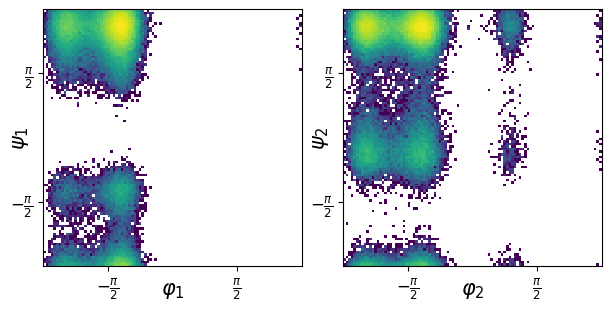

In [3]:

phis_data = md.compute_phi(traj_samples_data[:100000])[1]
psis_data = md.compute_psi(traj_samples_data[:100000])[1]

fig, axs = plt.subplots(1, 2, figsize=(6, 3), constrained_layout=True)
plot_range = [-np.pi, np.pi]
for i in range(phis_data.shape[1]):
    ax = axs[i]
    h1, x_bins1, y_bins1, im1 = ax.hist2d(
        phis_data[:, i], psis_data[:, i], 100, 
        norm=LogNorm(), range=[plot_range, plot_range], rasterized=True
    )
    ax.set_xlabel(rf"$\varphi_{i+1}$", labelpad=-15, fontsize=15)#, fontsize=45)
    ax.set_ylabel(rf"$\psi_{i+1}$", labelpad=-15, fontsize=15)#, fontsize=45)
    ax.set_xticks([-np.pi / 2, np.pi/ 2])
    ax.set_xticklabels([r"$-\frac{\pi}{2}$", r"$\frac{\pi}{2}$"], fontsize=12)
    ax.set_yticks([-np.pi / 2, np.pi/ 2])
    ax.set_yticklabels([r"$-\frac{\pi}{2}$", r"$\frac{\pi}{2}$"], fontsize=12)

plt.savefig("ramachandran.png", dpi=300)
plt.show()

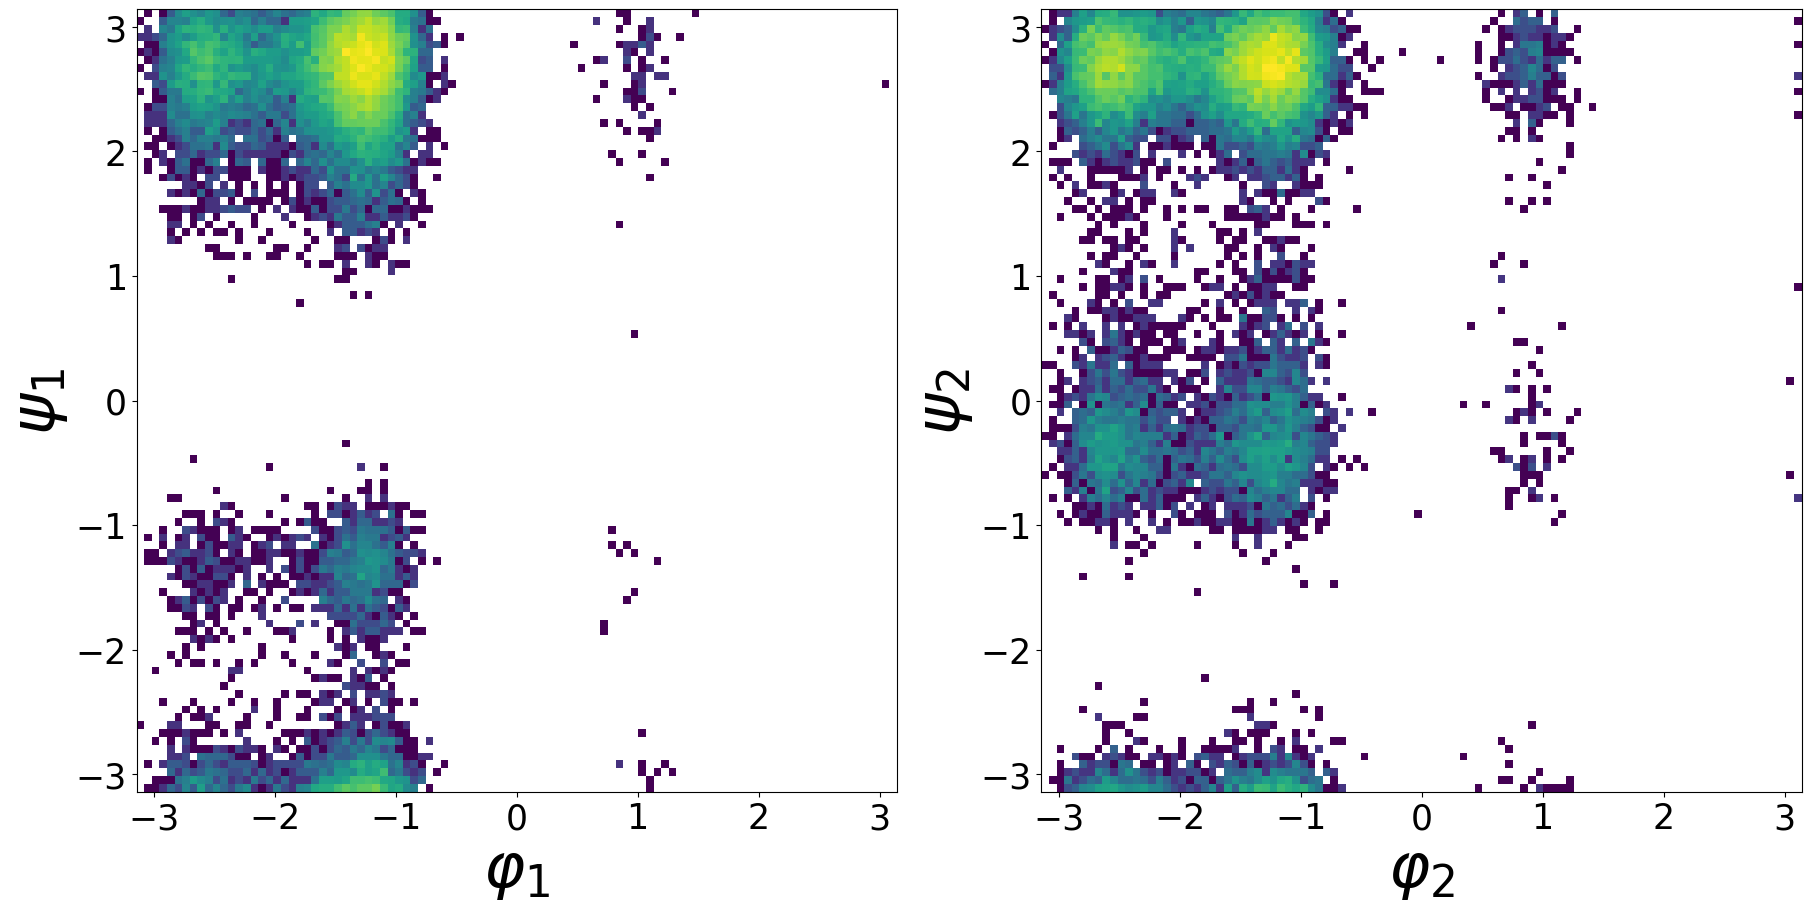

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)

plot_range = [-np.pi, np.pi]
phis_data = md.compute_phi(traj_samples_data[100000:120000])[1]
psis_data = md.compute_psi(traj_samples_data[100000:120000])[1]

h1, x_bins1, y_bins1, im1 = axs[0].hist2d(
    phis_data[:, 0], psis_data[:, 0], 100, 
    norm=LogNorm(), range=[plot_range, plot_range], rasterized=True
)
axs[0].set_xlabel(r"$\varphi_1$", fontsize=45)
#axs[0].set_title("MD (First)", fontsize=45)
axs[0].set_ylabel(r"$\psi_1$", fontsize=45)
axs[0].xaxis.set_tick_params(labelsize=25)
axs[0].yaxis.set_tick_params(labelsize=25)

# Second subplot
h2, x_bins2, y_bins2, im2 = axs[1].hist2d(
    phis_data[:, 1], psis_data[:, 1], 100, 
    norm=LogNorm(), range=[plot_range, plot_range], rasterized=True
)
axs[1].set_xlabel(r"$\varphi_2$", fontsize=45)
#axs[1].set_title("MD (Second)", fontsize=45)
axs[1].set_ylabel(r"$\psi_2$", fontsize=45)
axs[1].xaxis.set_tick_params(labelsize=25)
axs[1].yaxis.set_tick_params(labelsize=25)
plt.savefig("AlaAlaAlaRama_val.png", dpi=300)
plt.show()

100000


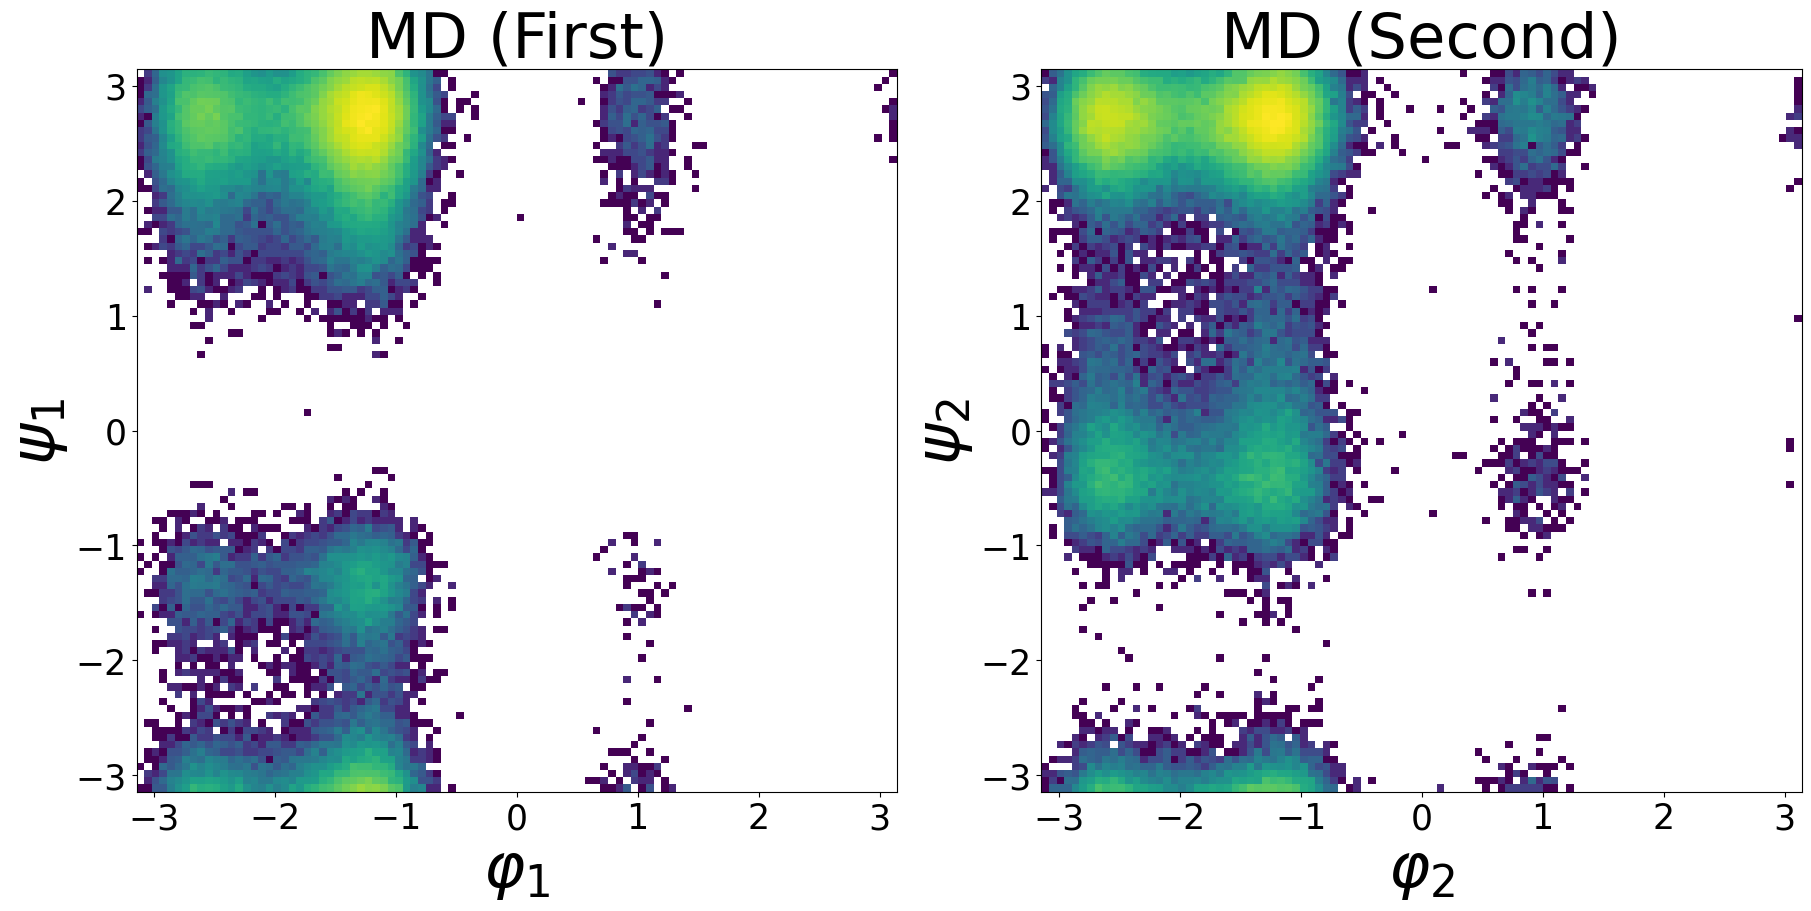

In [5]:
samples = all_positions_np[120_000:]
test_rng = np.random.default_rng(1)
samples = test_rng.permutation(samples)[:100_000]
samples = md.Trajectory(samples, topology=topology)
print(len(samples))
fig, axs = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)

plot_range = [-np.pi, np.pi]
phis_data = md.compute_phi(traj_samples_data[-100000:])[1]
psis_data = md.compute_psi(traj_samples_data[-100000:])[1]

h1, x_bins1, y_bins1, im1 = axs[0].hist2d(
    phis_data[:, 0], psis_data[:, 0], 100, 
    norm=LogNorm(), range=[plot_range, plot_range], rasterized=True
)
axs[0].set_xlabel(r"$\varphi_1$", fontsize=45)
axs[0].set_title("MD (First)", fontsize=45)
axs[0].set_ylabel(r"$\psi_1$", fontsize=45)
axs[0].xaxis.set_tick_params(labelsize=25)
axs[0].yaxis.set_tick_params(labelsize=25)

# Second subplot
h2, x_bins2, y_bins2, im2 = axs[1].hist2d(
    phis_data[:, 1], psis_data[:, 1], 100, 
    norm=LogNorm(), range=[plot_range, plot_range], rasterized=True
)
axs[1].set_xlabel(r"$\varphi_2$", fontsize=45)
axs[1].set_title("MD (Second)", fontsize=45)
axs[1].set_ylabel(r"$\psi_2$", fontsize=45)
axs[1].xaxis.set_tick_params(labelsize=25)
axs[1].yaxis.set_tick_params(labelsize=25)
plt.savefig("AlaAlaAlaRama_test.png", dpi=300)
plt.show()

## Ramachandran plots

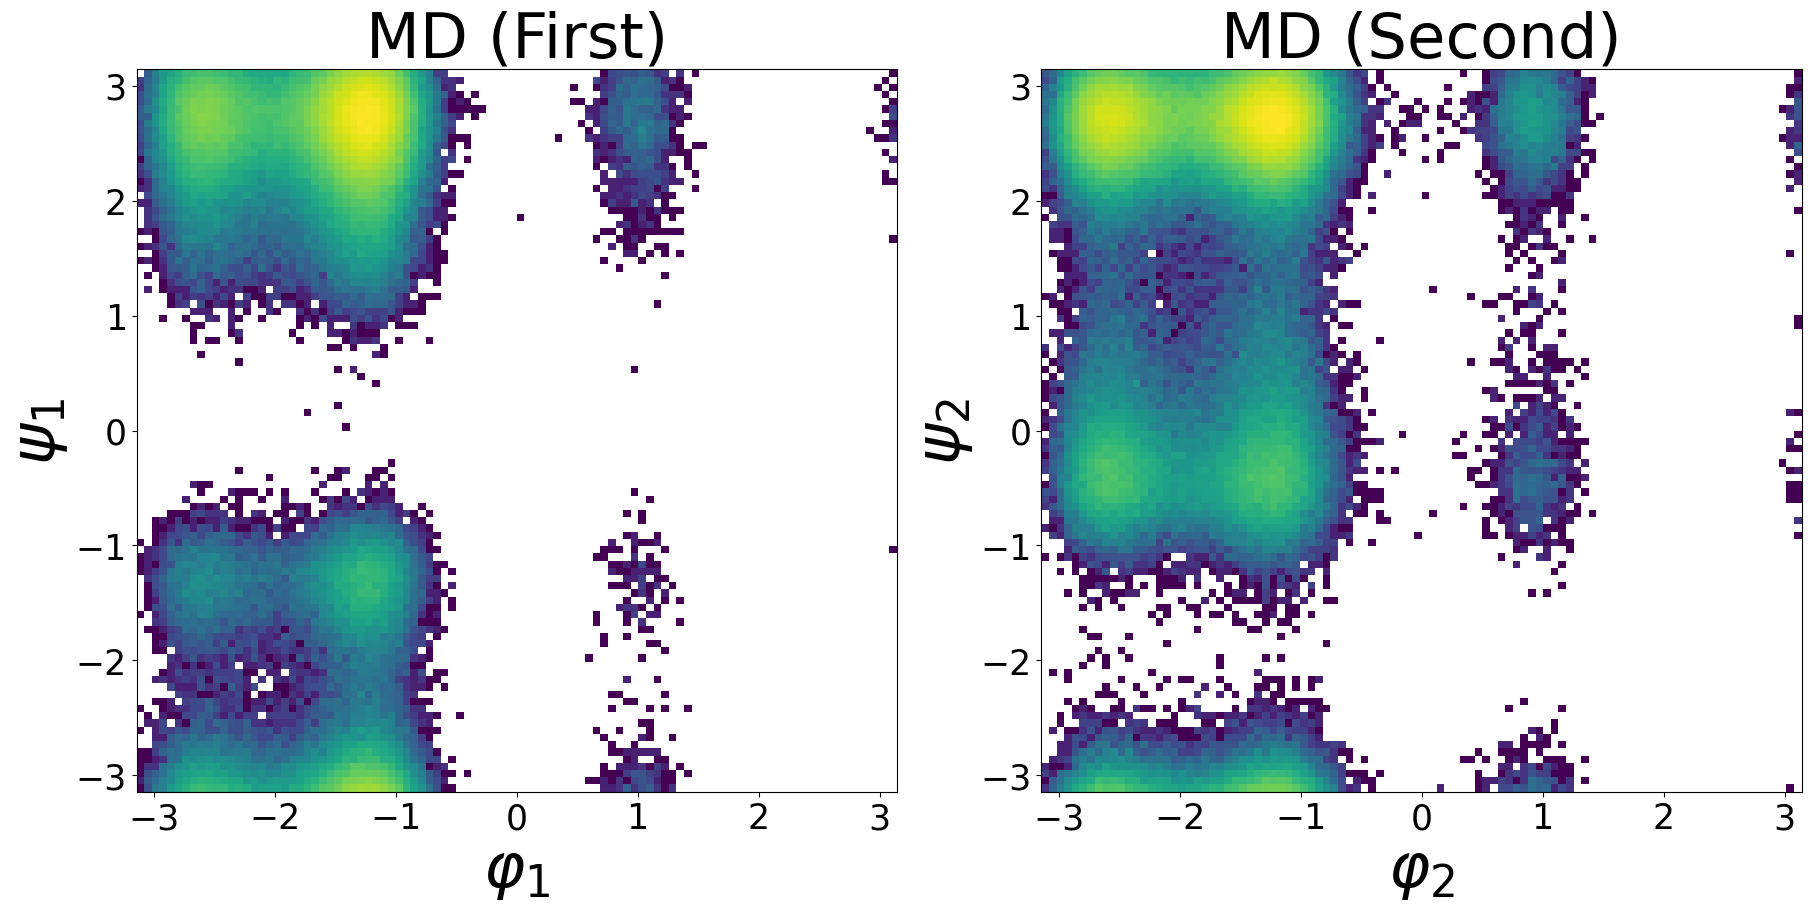

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)

plot_range = [-np.pi, np.pi]
phis_data = md.compute_phi(traj_samples_data)[1]
psis_data = md.compute_psi(traj_samples_data)[1]

h1, x_bins1, y_bins1, im1 = axs[0].hist2d(
    phis_data[:, 0], psis_data[:, 0], 100, 
    norm=LogNorm(), range=[plot_range, plot_range], rasterized=True
)
axs[0].set_xlabel(r"$\varphi_1$", fontsize=45)
axs[0].set_title("MD (First)", fontsize=45)
axs[0].set_ylabel(r"$\psi_1$", fontsize=45)
axs[0].xaxis.set_tick_params(labelsize=25)
axs[0].yaxis.set_tick_params(labelsize=25)

# Second subplot
h2, x_bins2, y_bins2, im2 = axs[1].hist2d(
    phis_data[:, 1], psis_data[:, 1], 100, 
    norm=LogNorm(), range=[plot_range, plot_range], rasterized=True
)
axs[1].set_xlabel(r"$\varphi_2$", fontsize=45)
axs[1].set_title("MD (Second)", fontsize=45)
axs[1].set_ylabel(r"$\psi_2$", fontsize=45)
axs[1].xaxis.set_tick_params(labelsize=25)
axs[1].yaxis.set_tick_params(labelsize=25)
plt.savefig("AlaAlaAlaRama.png", dpi=300)
plt.show()

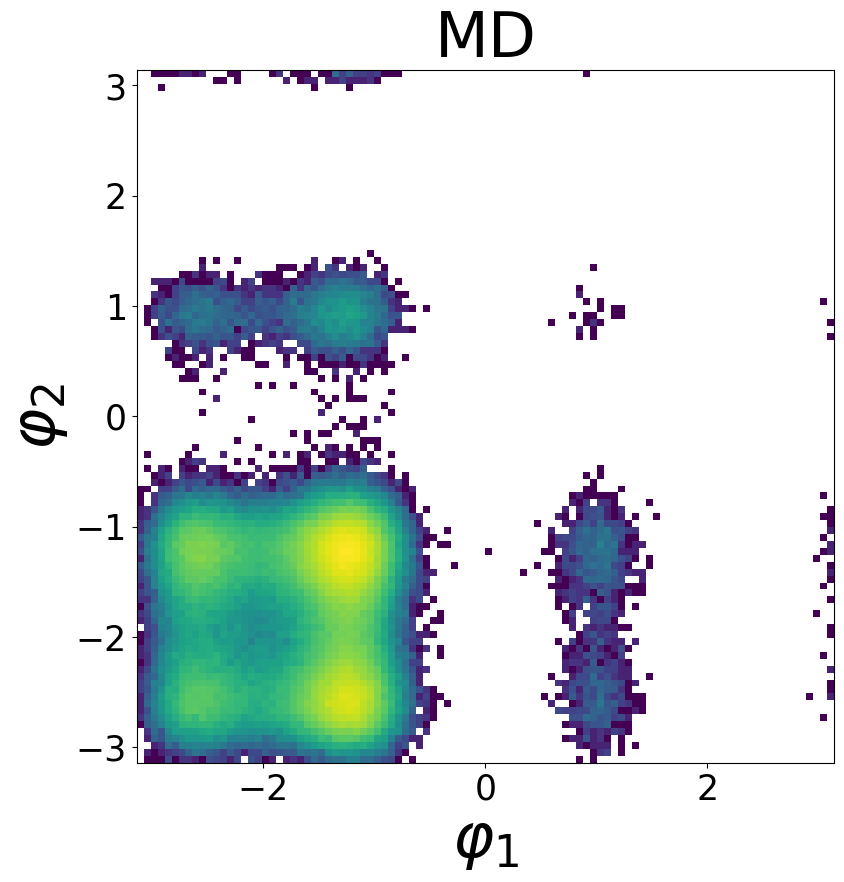

In [7]:
fig, ax = plt.subplots(figsize=(9, 9))
plot_range = [-np.pi, np.pi]
h, x_bins, y_bins, im = ax.hist2d(phis_data[:, 0], phis_data[:,1], 100, norm=LogNorm(), range=[plot_range,plot_range],rasterized=True)
ticks = np.array([np.exp(-6)*h.max(), np.exp(-4.0)*h.max(),np.exp(-2)*h.max(), h.max()])
ax.set_xlabel(r"$\varphi_1$", fontsize=45)
ax.set_title("MD", fontsize=45)
ax.set_ylabel(r"$\varphi_2$", fontsize=45)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)

## Energies

In [8]:
from bgflow import OpenMMBridge, OpenMMEnergy
import openmm
import torch
from openmm import app



pdb = app.PDBFile("../data/alanine/AlaAlaAla_310K.pdb")

forcefield = app.ForceField("amber14-all.xml", "implicit/obc1.xml")

system = forcefield.createSystem(pdb.topology, nonbondedMethod=openmm.app.CutoffNonPeriodic,
        nonbondedCutoff=2.0*openmm.unit.nanometer, constraints=None)
integrator = openmm.LangevinMiddleIntegrator(310*openmm.unit.kelvin, 0.3/openmm.unit.picosecond, 1.0*openmm.unit.femtosecond)
openmm_energy = OpenMMEnergy(bridge=OpenMMBridge(system, integrator, platform_name="CPU"))


/network/scratch/a/alexander.tong/micromamba/envs/tbg4/lib/python3.11/site-packages/bgflow/distribution/energy/openmm.py:200: UserWarning: It looks like you are using an OpenMMBridge with multiple workers in an ipython environment. This can behave a bit silly upon KeyboardInterrupt (e.g., kill the stdout stream). If you experience any issues, consider initializing the bridge with n_workers=1 in ipython/jupyter.
  warnings.warn(


In [9]:
# this might take a while 
energies = openmm_energy.energy(torch.from_numpy(all_positions_np).reshape(-1, 99)).numpy()

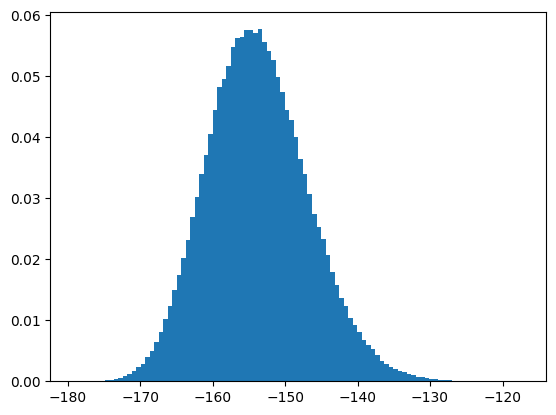

In [10]:
plt.hist(energies, bins=100, density=True);

In [11]:
import nglview as nv
import mdtraj as md
traj_samples_data = md.Trajectory(all_positions_np.reshape(-1, 33, 3), topology=topology)

view = nv.show_mdtraj(traj_samples_data)

view

NGLWidget(max_frame=305100)

In [22]:
atom_types = np.arange(33)
atom_types[[1, 2, 3]] = 2
atom_types[[9, 10, 11]] = 10
atom_types[[19,20,21]] = 18
atom_types[[29, 30, 31]] = 31

h_initial = torch.nn.functional.one_hot(torch.tensor(atom_types))



In [13]:
view.__dict__

{'_trait_values': {'_ibtn_fullscreen': Button(icon='compress', layout=Layout(width='34px'), style=ButtonStyle()),
  '_igui': None,
  '_image_data': '',
  '_init_gui': False,
  '_iplayer': HBox(children=(Play(value=0, max=305100), IntSlider(value=0, max=305100))),
  '_model_module': 'nglview-js-widgets',
  '_model_module_version': '3.1.4',
  '_model_name': 'NGLModel',
  '_ngl_serialize': False,
  '_ngl_version': '2.2.2',
  '_send_binary': True,
  '_view_count': None,
  '_view_height': '',
  '_view_module': 'nglview-js-widgets',
  '_view_module_version': '3.1.4',
  '_view_name': 'NGLView',
  '_view_width': '',
  'background': 'white',
  'comm': <ipykernel.comm.comm.BaseComm at 0x7f3cb97f9290>,
  'frame': 0,
  'loaded': True,
  'max_frame': 305100,
  'n_components': 1,
  'tabbable': None,
  'tooltip': None,
  'keys': ['_camera_orientation',
   '_camera_str',
   '_dom_classes',
   '_gui_theme',
   '_ibtn_fullscreen',
   '_igui',
   '_iplayer',
   '_model_module',
   '_model_module_version'